# Stock Analysis
Overview:
stocks Analyzed
- BEL
- Tata Steel
- Reliance
- Bharti Airtel
Analysis Performed
- Historical closing prices
- Normalized price comparison
- Daily returns
- Daily and annualized volatility
- Return correlation
- Cumulative returns
Tools
Python, Pandas, NumPy, Matplotlib, Seaborn, yFinance

In [123]:
!pip install yfinance

In [124]:
import pandas as pd
import numpy as np
import seaborn as sns

In [125]:
import yfinance as yf
data = yf.download("BEL.NS",start="2020-01-01",end="2026-10-01")

/tmp/ipykernel_2083/773766828.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BEL.NS",start="2020-01-01",end="2026-10-01")
[*********************100%***********************]  1 of 1 completed


In [126]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,BEL.NS,BEL.NS,BEL.NS,BEL.NS,BEL.NS
Date,,,,,
2020-01-01,29.673443,29.910478,29.451225,29.717889,15438294
2020-01-02,30.562309,30.754898,29.599368,29.821585,26262750
2020-01-03,29.910463,30.784515,29.732689,30.577116,21950223
2020-01-06,28.725311,29.895656,28.340135,29.480849,36402729
2020-01-07,28.547533,29.332703,28.236430,29.140114,33298260


In [127]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BEL.NS,BEL.NS,BEL.NS,BEL.NS,BEL.NS
Date,,,,,
2026-09-24,392.000000,398.049988,392.000000,394.000000,5841116
2026-09-25,393.549988,394.549988,388.600006,392.000000,6083441
2026-09-28,385.500000,393.450012,384.100006,393.450012,11661372
2026-09-29,387.750000,388.000000,382.200012,385.500000,13517154
2026-09-30,388.299988,391.000000,385.000000,386.399994,9671143


In [128]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,BEL.NS,BEL.NS,BEL.NS,BEL.NS,BEL.NS
count,1676.000000,1676.000000,1676.000000,1676.000000,1.676000e+03
mean,179.309856,181.697137,176.980181,179.538982,2.635871e+07
std,143.908185,145.498822,142.364248,144.138557,2.587755e+07
min,17.603054,18.431256,16.865201,17.407296,0.000000e+00
25%,60.821027,62.048120,59.183350,60.923467,1.224689e+07
50%,106.557697,108.095790,104.984408,106.701386,1.937230e+07
75%,298.155457,302.873292,294.343332,298.938057,3.161672e+07
max,467.814941,472.808163,459.725916,469.362825,3.638938e+08


In [129]:
data.shape

(1676, 5)

In [130]:
data.columns

MultiIndex([( 'Close', 'BEL.NS'),
            (  'High', 'BEL.NS'),
            (   'Low', 'BEL.NS'),
            (  'Open', 'BEL.NS'),
            ('Volume', 'BEL.NS')],
           names=['Price', 'Ticker'])

In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1676 entries, 2020-01-01 to 2026-09-30
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, BEL.NS)   1676 non-null   float64
 1   (High, BEL.NS)    1676 non-null   float64
 2   (Low, BEL.NS)     1676 non-null   float64
 3   (Open, BEL.NS)    1676 non-null   float64
 4   (Volume, BEL.NS)  1676 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 78.6 KB


In [132]:
data["Close"]

Ticker,BEL.NS
Date,
2020-01-01,29.673443
2020-01-02,30.562309
2020-01-03,29.910463
2020-01-06,28.725311
2020-01-07,28.547533
...,...
2026-09-24,392.000000
2026-09-25,393.549988
2026-09-28,385.500000


In [133]:
data["Close"].head()

Ticker,BEL.NS
Date,
2020-01-01,29.673443
2020-01-02,30.562309
2020-01-03,29.910463
2020-01-06,28.725311
2020-01-07,28.547533


In [134]:
data["Close"].head()

Ticker,BEL.NS
Date,
2020-01-01,29.673443
2020-01-02,30.562309
2020-01-03,29.910463
2020-01-06,28.725311
2020-01-07,28.547533


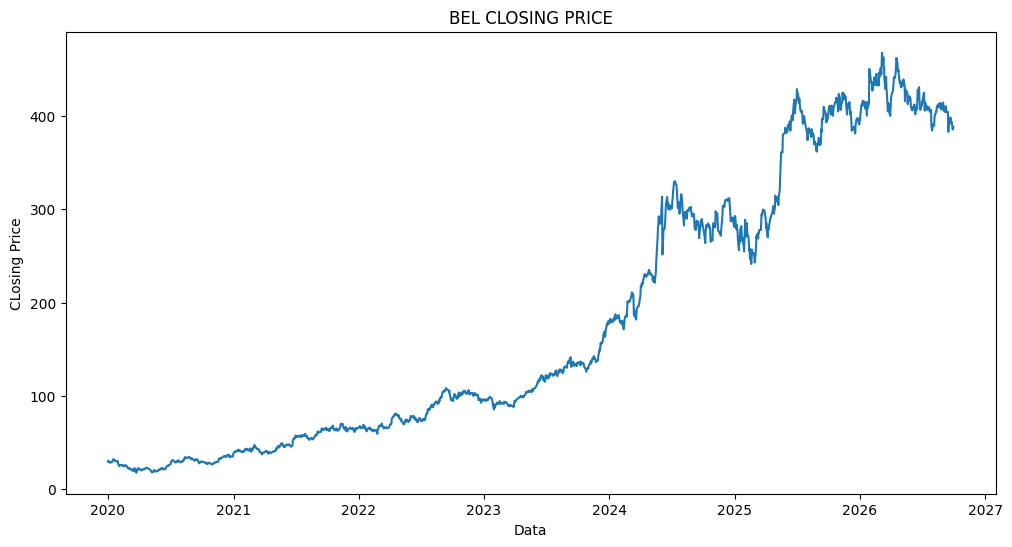

In [135]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(data["Close"])
plt.title("BEL CLOSING PRICE")
plt.xlabel("Data")
plt.ylabel("CLosing Price")
plt.show()

In [136]:
data["MA20"] = data["Close"].rolling(20).mean()
data["MA50"] = data["Close"].rolling(50).mean()

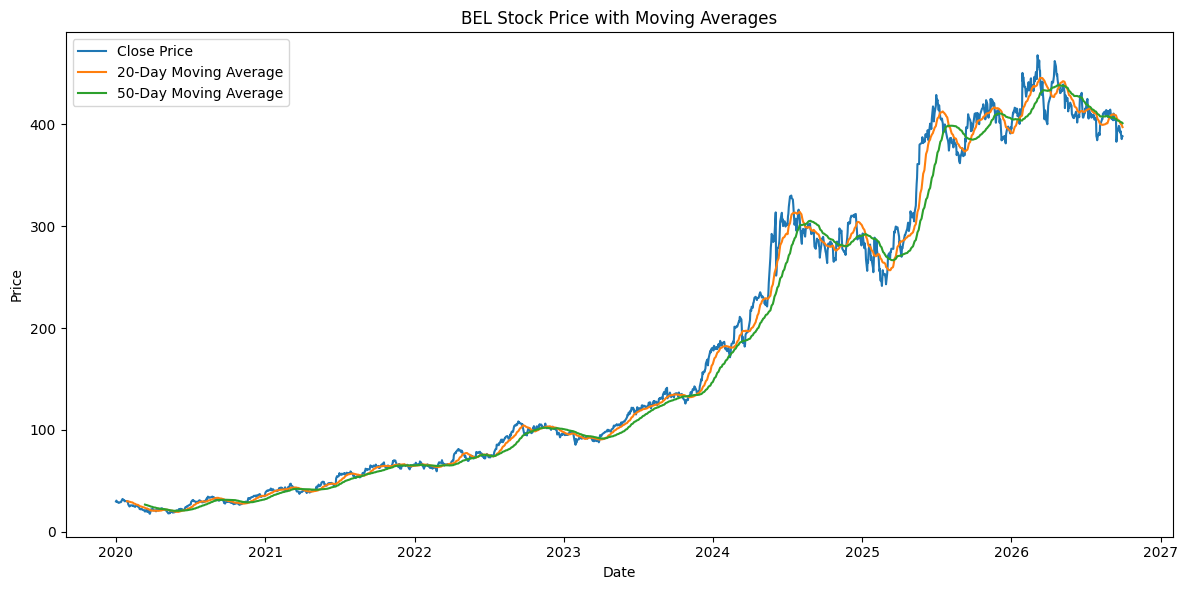

In [137]:
plt.figure(figsize=(12, 6))

plt.plot(data["Close"], label="Close Price")
plt.plot(data["MA20"], label="20-Day Moving Average")
plt.plot(data["MA50"], label="50-Day Moving Average")

plt.title("BEL Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.tight_layout()
plt.show()

In [138]:
data = data.drop(columns=["Daily Return"], errors="ignore")

In [139]:
data["Daily_Return"] = data["Close"].squeeze().pct_change()

In [140]:
data[["Close", "Daily_Return"]].head(10)

Price,Close,Daily_Return
Ticker,BEL.NS,
Date,,
2020-01-01,29.673443,NaN
2020-01-02,30.562309,0.029955
2020-01-03,29.910463,-0.021328
2020-01-06,28.725311,-0.039623
2020-01-07,28.547533,-0.006189
2020-01-08,28.280876,-0.009341
2020-01-09,28.740124,0.016239
2020-01-10,28.799385,0.002062


In [141]:
data["Daily_Return"].describe()

,Daily_Return
count,1675.000000
mean,0.001795
std,0.022647
min,-0.198023
25%,-0.009829
50%,0.000572
75%,0.013150
max,0.112946


In [142]:
(data["Daily_Return"] * 100).head(10)

,Daily_Return
Date,
2020-01-01,NaN
2020-01-02,2.995495
2020-01-03,-2.132843
2020-01-06,-3.962333
2020-01-07,-0.618891
2020-01-08,-0.934080
2020-01-09,1.623880
2020-01-10,0.206197
2020-01-13,0.823052


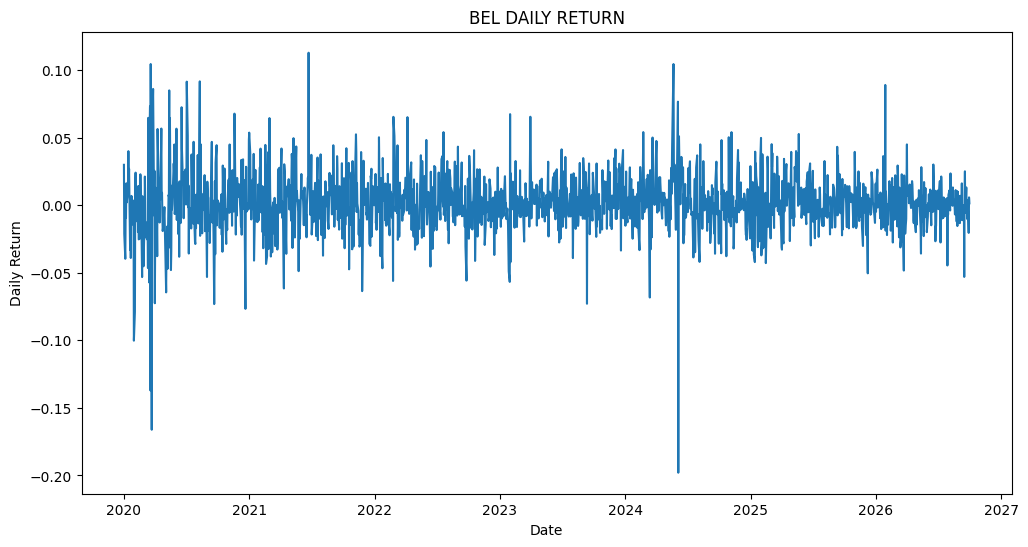

In [143]:
plt.figure(figsize=(12,6))
plt.plot(data["Daily_Return"])
plt.title("BEL DAILY RETURN")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

In [144]:
daily_volatility=data["Daily_Return"].std()
print("Daily Volatality:",daily_volatility)

Daily Volatality: 0.02264729375706647


In [145]:
daily_volatility = data["Daily_Return"].std()

annualized_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility:", daily_volatility)
print("Annualized Volatility:", annualized_volatility)

Daily Volatility: 0.02264729375706647
Annualized Volatility: 0.3595146428989412


In [146]:
data["Cumulative_Return"] = (1 + data["Daily_Return"]).cumprod() - 1

In [147]:
data[["Close", "Daily_Return", "Cumulative_Return"]].head(10)

Price,Close,Daily_Return,Cumulative_Return
Ticker,BEL.NS,,
Date,,,
2020-01-01,29.673443,NaN,NaN
2020-01-02,30.562309,0.029955,0.029955
2020-01-03,29.910463,-0.021328,0.007988
2020-01-06,28.725311,-0.039623,-0.031952
2020-01-07,28.547533,-0.006189,-0.037943
2020-01-08,28.280876,-0.009341,-0.046930
2020-01-09,28.740124,0.016239,-0.031453
2020-01-10,28.799385,0.002062,-0.029456


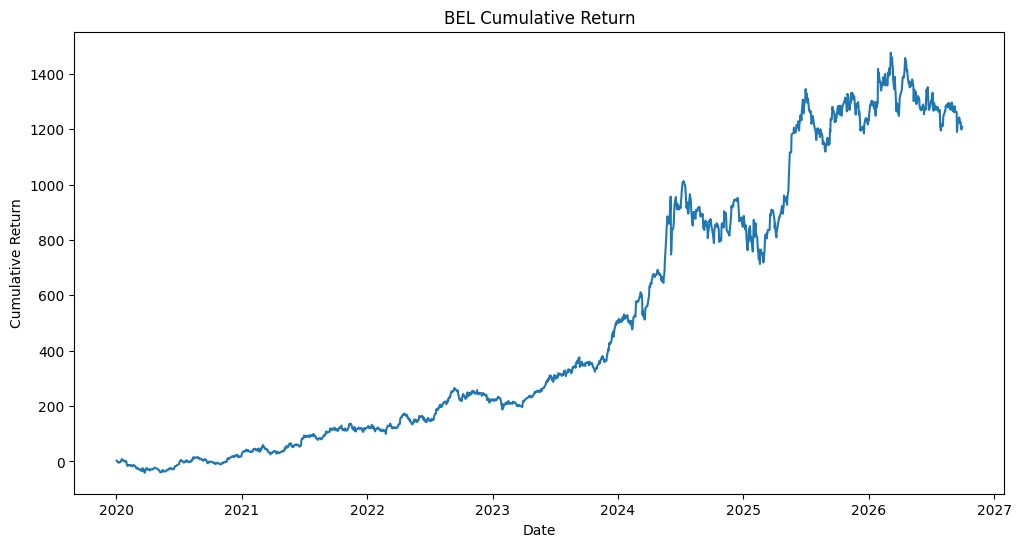

In [148]:
plt.figure(figsize=(12,6))
plt.plot(data["Cumulative_Return"]*100)
plt.title("BEL Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.show()

In [149]:
final_return = data["Cumulative_Return"].iloc[-1]

print("Total Cumulative Return:", final_return)

Total Cumulative Return: 12.085774707004976


In [150]:
stocks = {
    "BEL": "BEL.NS",
    "Tata Steel": "TATASTEEL.NS",
    "Reliance": "RELIANCE.NS",
    "Bharti Airtel": "BHARTIARTL.NS"
}

print(stocks)

{'BEL': 'BEL.NS', 'Tata Steel': 'TATASTEEL.NS', 'Reliance': 'RELIANCE.NS', 'Bharti Airtel': 'BHARTIARTL.NS'}


In [151]:
prices = pd.DataFrame()

for name, ticker in stocks.items():
    print("Downloading:", name)

    stock_data = yf.download(
        ticker,
        start="2010-01-01",
        end="2026-10-01"
    )

    prices[name] = stock_data["Close"].squeeze()

print(prices.columns)

/tmp/ipykernel_2083/3796136816.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(
[*********************100%***********************]  1 of 1 completed

Downloading: BEL
Downloading: Tata Steel



/tmp/ipykernel_2083/3796136816.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2083/3796136816.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2083/3796136816.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(
[*********************100%***********************]  1 of 1 completed


Downloading: Reliance
Downloading: Bharti Airtel
Index(['BEL', 'Tata Steel', 'Reliance', 'Bharti Airtel'], dtype='object')


In [152]:
prices.head()

,BEL,Tata Steel,Reliance,Bharti Airtel
Date,,,,
2010-01-04,15.038431,39.503933,217.587067,266.718933
2010-01-05,15.085142,40.460754,216.615936,270.942871
2010-01-06,14.983234,40.021309,220.115967,268.072235
2010-01-07,14.897918,40.504398,223.767715,270.163666
2010-01-08,14.909886,40.420238,223.180984,266.595947


In [153]:
returns = prices.pct_change()

In [154]:
returns.head()

,BEL,Tata Steel,Reliance,Bharti Airtel
Date,,,,
2010-01-04,NaN,NaN,NaN,NaN
2010-01-05,0.003106,0.024221,-0.004463,0.015837
2010-01-06,-0.006756,-0.010861,0.016158,-0.010595
2010-01-07,-0.005694,0.012071,0.016590,0.007802
2010-01-08,0.000803,-0.002078,-0.002622,-0.013206


In [155]:
returns.tail()

,BEL,Tata Steel,Reliance,Bharti Airtel
Date,,,,
2026-09-24,-0.010226,-0.014674,-0.023077,-0.020401
2026-09-25,0.003954,-0.000266,0.005577,-0.005791
2026-09-28,-0.020455,-0.008884,-0.023165,-0.007841
2026-09-29,0.005837,0.009125,-0.013026,-0.000113
2026-09-30,0.001418,-0.019681,0.004230,-0.008017


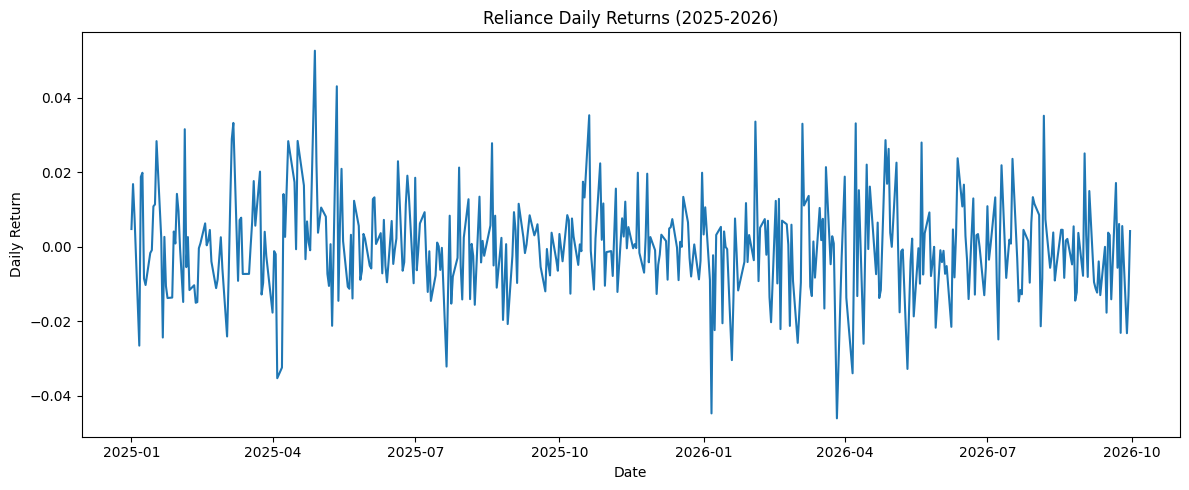

In [177]:
plt.figure(figsize=(12, 5))

plt.plot(
    returns.loc["2025-01-01":, "Reliance"]
)

plt.title("Reliance Daily Returns (2025-2026)")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.tight_layout()
plt.show()

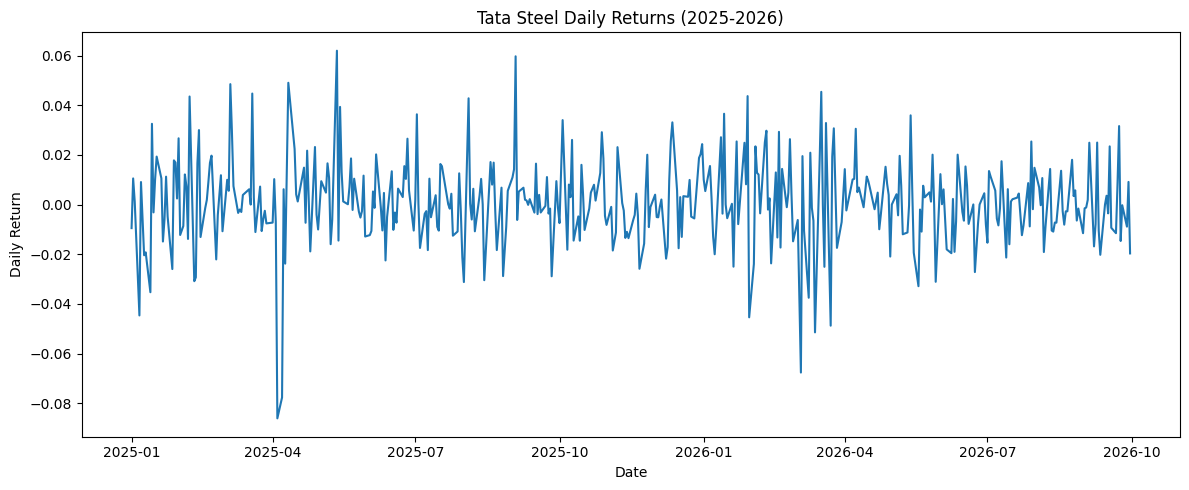

In [178]:
plt.figure(figsize=(12, 5))

plt.plot(
    returns.loc["2025-01-01":, "Tata Steel"]
)

plt.title("Tata Steel Daily Returns (2025-2026)")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.tight_layout()
plt.show()

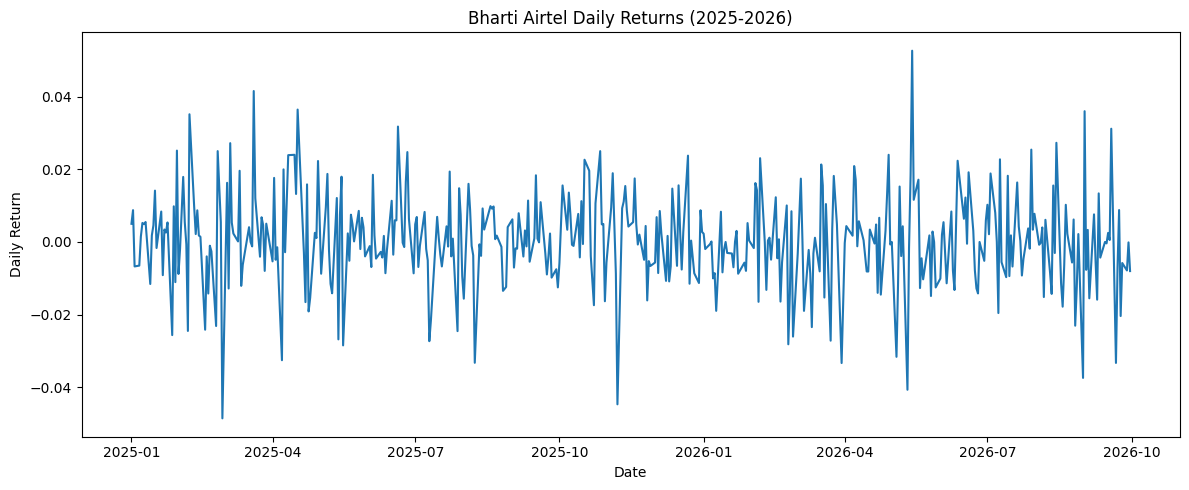

In [179]:
plt.figure(figsize=(12, 5))

plt.plot(
    returns.loc["2025-01-01":, "Bharti Airtel"]
)

plt.title("Bharti Airtel Daily Returns (2025-2026)")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.tight_layout()
plt.show()

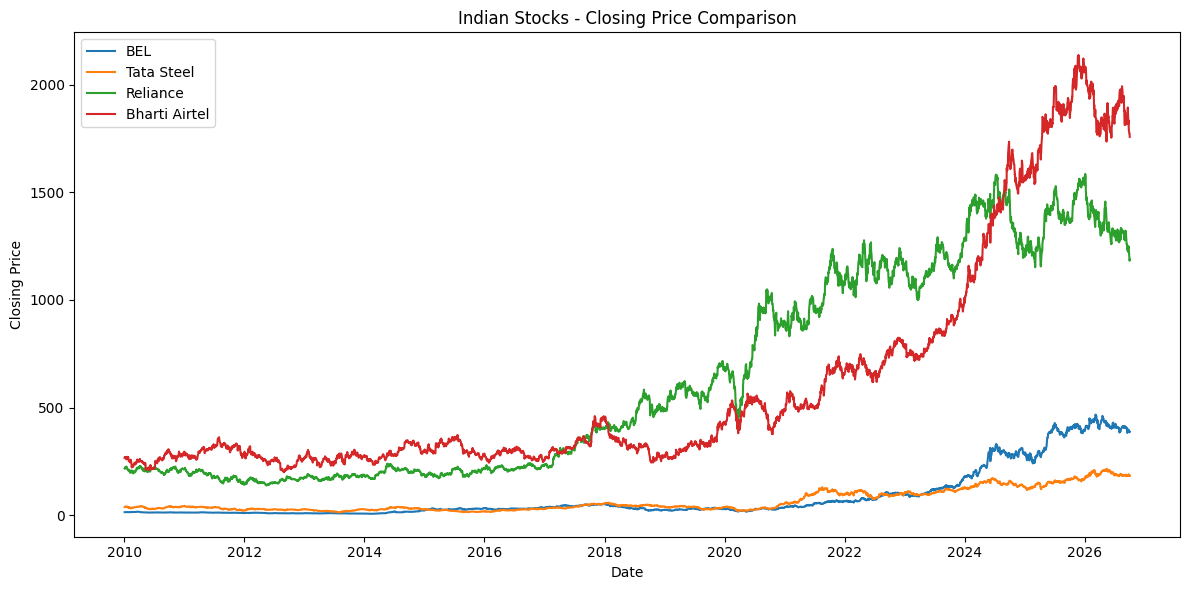

In [156]:
plt.figure(figsize=(12,6))
for column in prices.columns:
  plt.plot(prices[column], label=column)

plt.title("Indian Stocks - Closing Price Comparison")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.tight_layout()
plt.show()

In [157]:
normalized_prices = prices.div(prices.bfill().iloc[0]) * 100

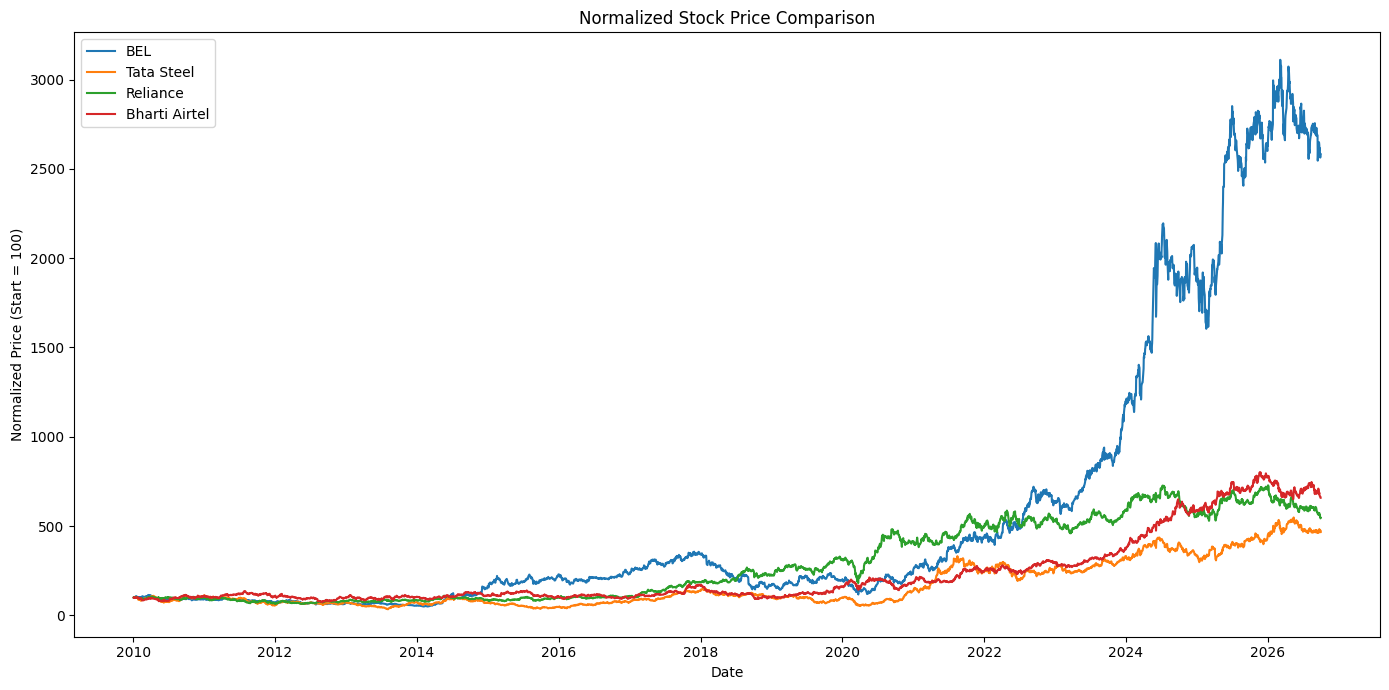

In [158]:
plt.figure(figsize=(14, 7))

for column in normalized_prices.columns:
    plt.plot(normalized_prices[column], label=column)

plt.title("Normalized Stock Price Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 100)")
plt.legend()
plt.tight_layout()
plt.show()

The normalized price comparison shows substantial differences in historical price appreciation among the selected stocks. BEL experienced the largest increase relative to its starting price, while Bharti Airtel, Reliance, and Tata Steel showed comparatively lower cumulative price appreciation over the selected period

In [159]:
returns = prices.pct_change()

In [160]:
returns.head()

,BEL,Tata Steel,Reliance,Bharti Airtel
Date,,,,
2010-01-04,NaN,NaN,NaN,NaN
2010-01-05,0.003106,0.024221,-0.004463,0.015837
2010-01-06,-0.006756,-0.010861,0.016158,-0.010595
2010-01-07,-0.005694,0.012071,0.016590,0.007802
2010-01-08,0.000803,-0.002078,-0.002622,-0.013206


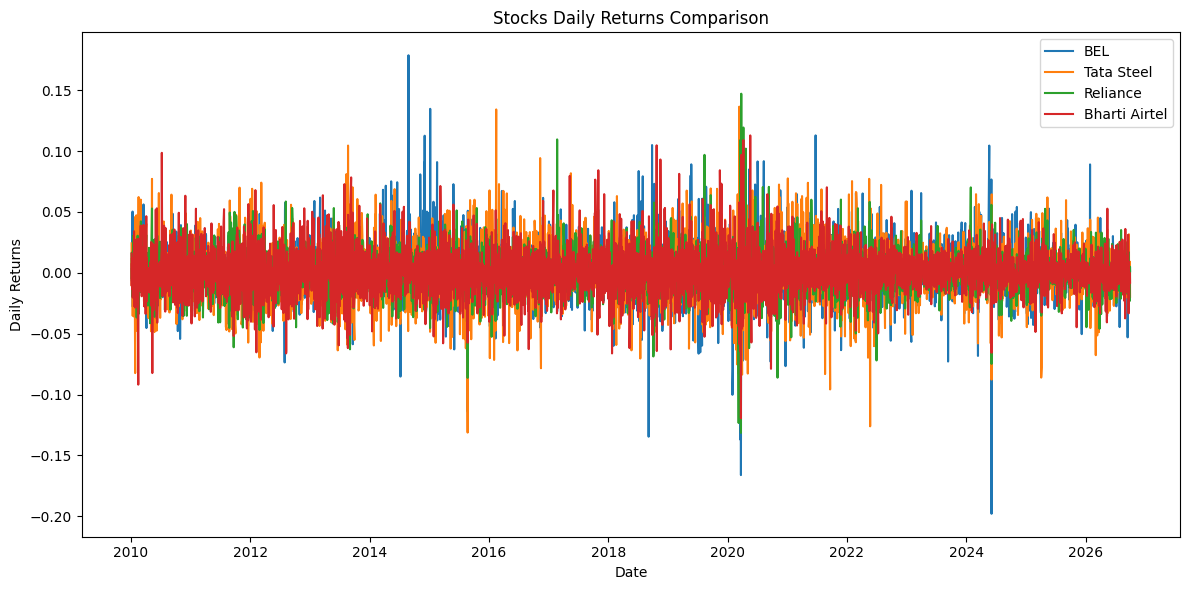

In [161]:
plt.figure(figsize=(12,6))
for column in prices.columns:
  plt.plot(returns[column],label=column)

plt.title("Stocks Daily Returns Comparison")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.legend()
plt.tight_layout()
plt.show()

In [162]:
daily_volatility = returns.std()
print(daily_volatility)

BEL              0.021206
Tata Steel       0.022309
Reliance         0.016865
Bharti Airtel    0.018778
dtype: float64


In [163]:
annualized_volatility = daily_volatility * np.sqrt(252)

annualized_volatility

,0
BEL,0.336630
Tata Steel,0.354142
Reliance,0.267718
Bharti Airtel,0.298093


In [164]:
correlation = returns.corr()
correlation

,BEL,Tata Steel,Reliance,Bharti Airtel
BEL,1.000000,0.328377,0.289074,0.187891
Tata Steel,0.328377,1.000000,0.401917,0.282338
Reliance,0.289074,0.401917,1.000000,0.280867
Bharti Airtel,0.187891,0.282338,0.280867,1.000000


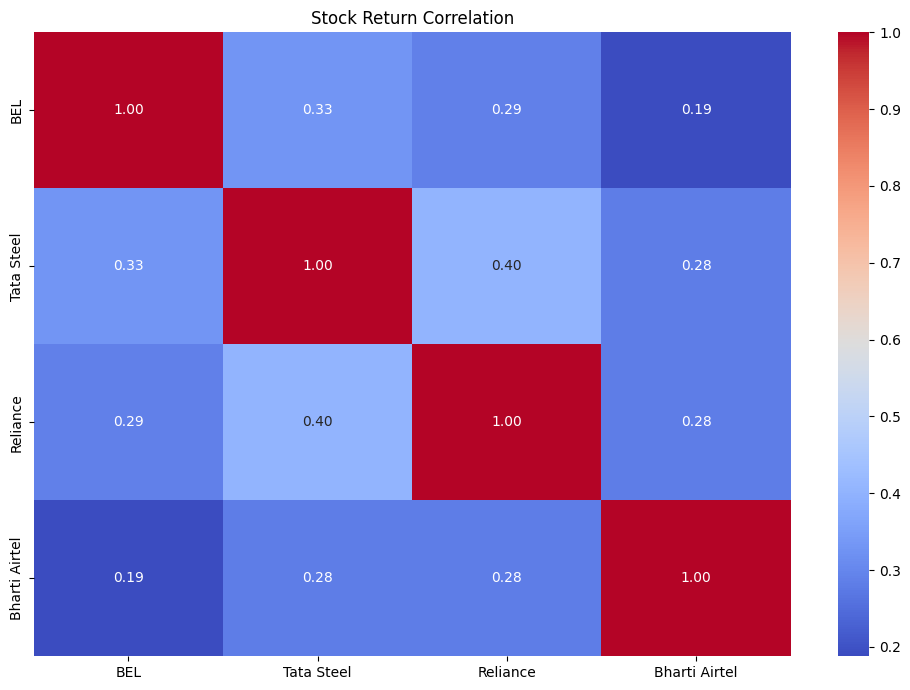

In [165]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Stock Return Correlation")
plt.tight_layout()
plt.show()

In [166]:
returns = prices.pct_change()

In [167]:
cumulative_returns = (1 + returns).cumprod() - 1

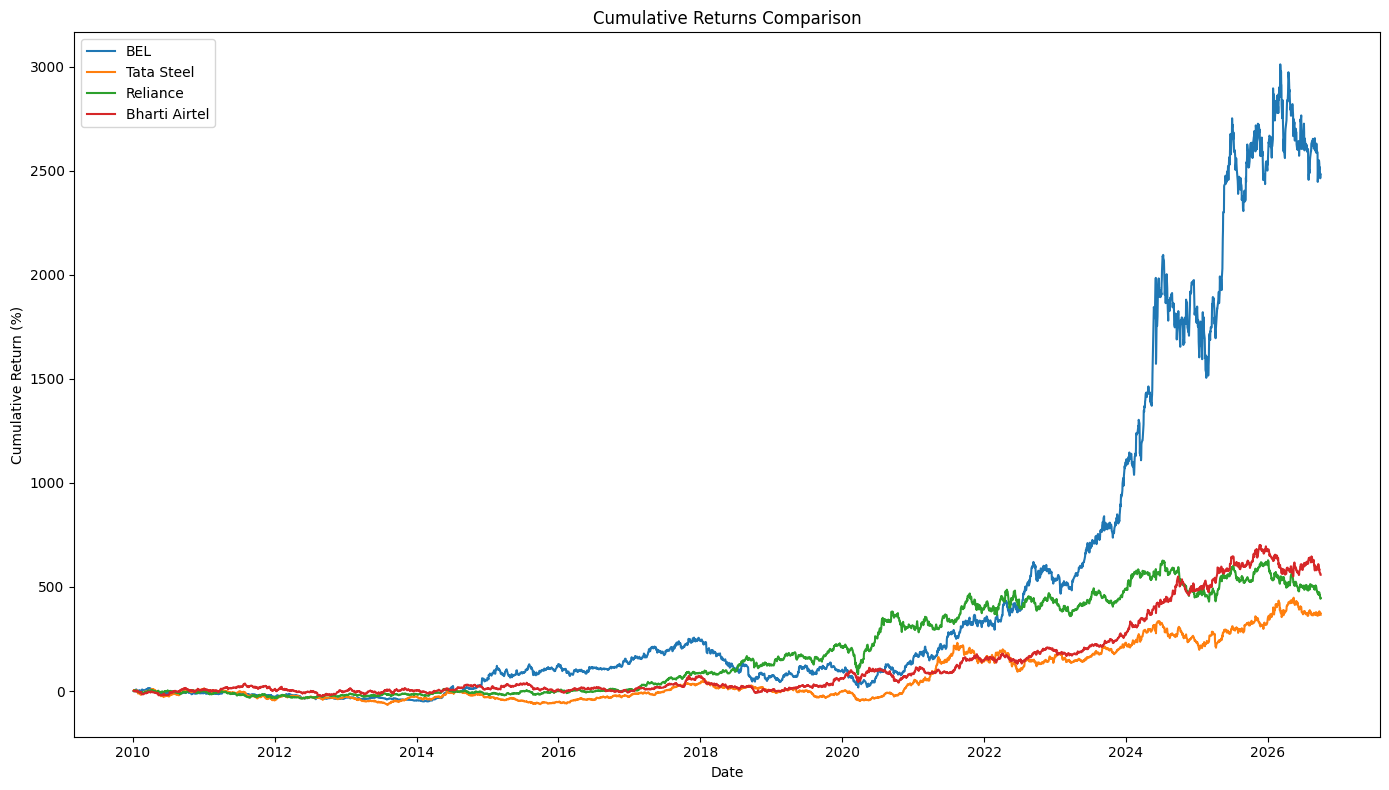

In [169]:
plt.figure(figsize=(14, 8))

for column in cumulative_returns.columns:
    plt.plot(
        cumulative_returns[column] * 100,
        label=column
    )

plt.title("Cumulative Returns Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.tight_layout()
plt.show()

The selected stocks Tata steel ,Reliance ,Airtel exhibit broadly similar patterns of daily market movement, but their individual returns and volatility differ. Their relatively low-to-moderate correlations indicate that they do not move identically.

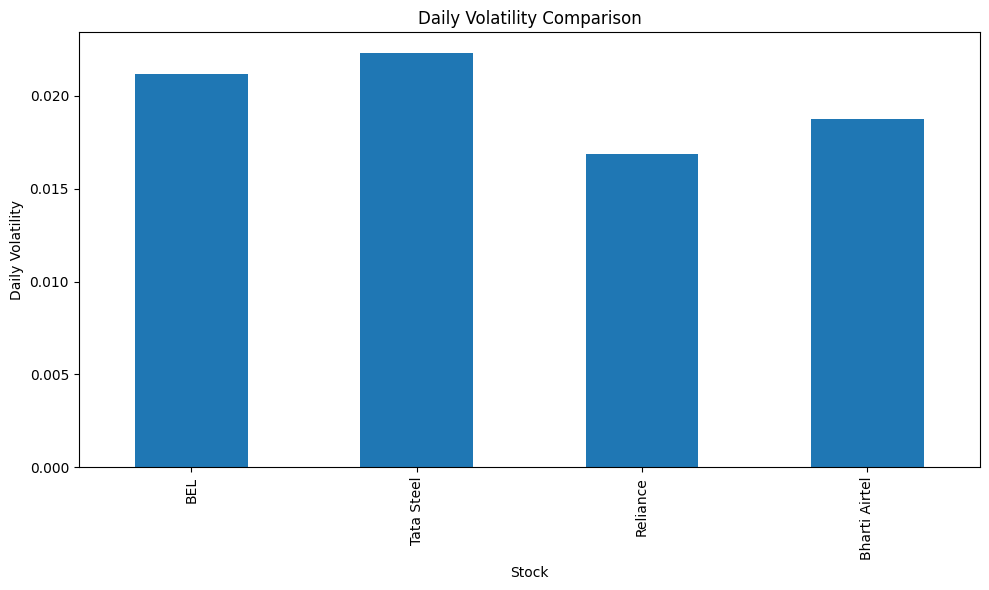

In [180]:
plt.figure(figsize=(10, 6))

daily_volatility.plot(kind="bar")

plt.title("Daily Volatility Comparison")
plt.xlabel("Stock")
plt.ylabel("Daily Volatility")

plt.tight_layout()
plt.show()

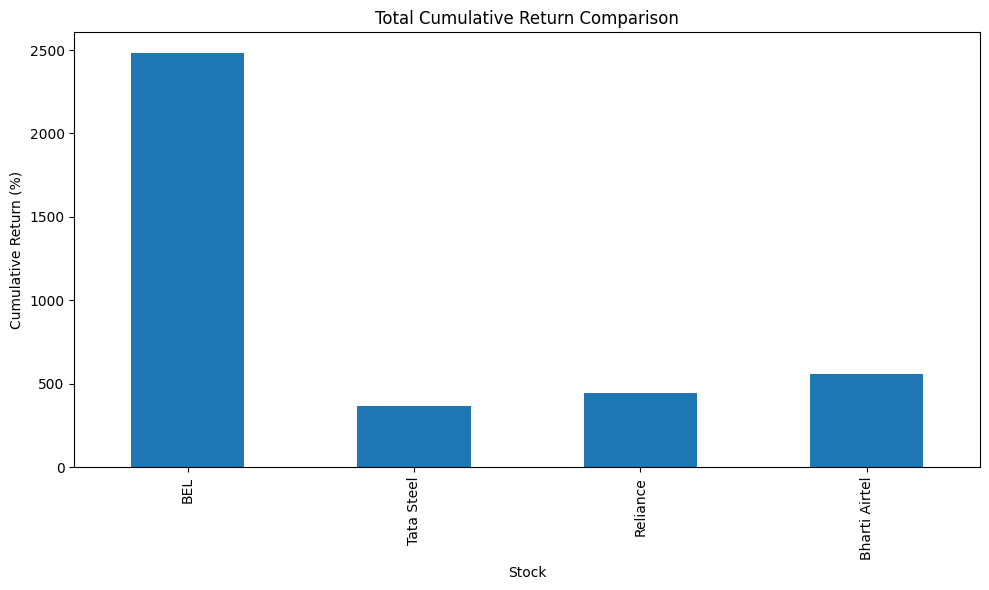

In [181]:
final_returns = cumulative_returns.iloc[-1] * 100

plt.figure(figsize=(10, 6))

final_returns.plot(kind="bar")

plt.title("Total Cumulative Return Comparison")
plt.xlabel("Stock")
plt.ylabel("Cumulative Return (%)")

plt.tight_layout()
plt.show()

In [170]:
summary = pd.DataFrame({
    "Average Daily Return": returns.mean(),
    "Daily Volatility": returns.std(),
    "Annualized Volatility": returns.std() * np.sqrt(252)
})

summary

,Average Daily Return,Daily Volatility,Annualized Volatility
BEL,0.001011,0.021206,0.336630
Tata Steel,0.000621,0.022309,0.354142
Reliance,0.000552,0.016865,0.267718
Bharti Airtel,0.000631,0.018778,0.298093


In [171]:
final_returns = cumulative_returns.iloc[-1] * 100

summary["Cumulative Return (%)"] = final_returns

summary

,Average Daily Return,Daily Volatility,Annualized Volatility,Cumulative Return (%)
BEL,0.001011,0.021206,0.336630,2482.051169
Tata Steel,0.000621,0.022309,0.354142,366.535834
Reliance,0.000552,0.016865,0.267718,445.528748
Bharti Airtel,0.000631,0.018778,0.298093,558.745886


#Key Findings

- BEL generated the highest cumulative return among the selected stocks over the analyzed period.

- The normalized price comparison shows that the four stocks experienced different levels of long-term price growth over the analysis period.

- Tata Steel had the highest daily volatility among the selected stocks, while Reliance had the lowest daily volatility. This indicates that Tata Steel's historical daily price movements were larger on average.

- The selected stocks showed positive but relatively low-to-moderate correlations. Tata Steel and Reliance had the highest correlation among the selected stocks, at approximately 0.40.

- The cumulative return analysis shows that the stocks produced substantially different long-term price returns over the selected period.

- Daily returns for all four stocks fluctuated around zero, with occasional periods of larger positive and negative movements.

- The analysis demonstrates that stocks from different sectors can experience different levels of return and volatility even when they are exposed to broader market movements.